# Greeks and Sensitivity Analysis

## 1. Research Objective

Now we have outlined some common models used in option pricing theory, we can move onto an analysis of how these prices react to changes in the underlying conditions. The Greeks measure an options' sensitivity to changes in asset price, volatility, time to maturity and interest rates. 

## 2. Black-Scholes Model

Recall the theory of Black-Scholes, a European call option is:

$$ C = S_0 N(d_1) - K e^{-rT} N(d_2) $$

And a European put option is:

$$ P = K e^{-rT} N(-d_2) - S_0 N(-d_1) $$

where $d_1 = \frac{\ln(S_0/K) + (r + \frac{1}{2} \sigma^2)T}{\sigma \sqrt{T}}$

and $d_2 = d_1 - \sigma \sqrt{T}$

## 3. Option Sensitivities

Let $V$ denote the value of an option.

Delta measures sensitivity to the underlying asset price:

$\Delta=\frac{\partial V}{\partial S_0}$

Gamma measures the rate of change of Delta:

$\Gamma=\frac{\partial^2 V}{\partial S_0^2}$

Vega measures sensitivity to volatility:

$\text{Vega}=\frac{\partial V}{\partial \sigma}$

Theta measures sensitivity to the passage of time:

$\Theta=\frac{\partial V}{\partial t}$

Rho measures sensitivity to the risk-free interest rate:

$\rho=\frac{\partial V}{\partial r}$

## 4. Black-Scholes Pricing Function

We also introduce the previous code seen in the Black-Scholes Option Pricing Notebook to begin our calculations of the Greeks.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

def black_scholes_price(S, K, r, sigma, T, option_type="call"):
    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return (
            S * norm.cdf(d1)
            - K * np.exp(-r * T) * norm.cdf(d2)
        )

    if option_type == "put":
        return (
            K * np.exp(-r * T) * norm.cdf(-d2)
            - S * norm.cdf(-d1)
        )

    raise ValueError("option_type must be 'call' or 'put'")

call_price = black_scholes_price(
    S0, K, r, sigma, T, option_type="call"
)

put_price = black_scholes_price(
    S0, K, r, sigma, T, option_type="put"
)

print(f"European Call Price: {call_price:.4f}")
print(f"European Put Price: {put_price:.4f}")

European Call Price: 10.4506
European Put Price: 5.5735


## 5. Analytical Greeks

### 5.1 Theory 

The Black–Scholes model can be used to give close approximations of the Greeks.

For a European call option,

$$
\Delta = N(d_1),
$$

$$
\Gamma = \frac{N'(d_1)}{S_0\sigma\sqrt{T}},
$$

$$
\text{Vega} = S_0N'(d_1)\sqrt{T},
$$

$$
\Theta =
-\frac{S_0N'(d_1)\sigma}{2\sqrt{T}}
-rKe^{-rT}N(d_2),
$$

$$
\rho = KTe^{-rT}N(d_2),
$$

where $N(\cdot)$ denotes the standard normal cumulative distribution function and $N'(\cdot)$ is the corresponding probability density function.

### 5.2 Greeks Calculations

In [5]:
d1 = (
    np.log(S0 / K)
    + (r + 0.5 * sigma**2) * T
) / (sigma * np.sqrt(T))

d2 = d1 - sigma * np.sqrt(T)

delta = norm.cdf(d1)

gamma = (
    norm.pdf(d1)
    / (S0 * sigma * np.sqrt(T))
)

vega = (
    S0
    * norm.pdf(d1)
    * np.sqrt(T)
)

theta = (
    -S0 * norm.pdf(d1) * sigma
    / (2 * np.sqrt(T))
    - r * K * np.exp(-r * T) * norm.cdf(d2)
)

rho = (
    K
    * T
    * np.exp(-r * T)
    * norm.cdf(d2)
)

greeks = pd.DataFrame(
    {
        "Greek": [
            "Delta",
            "Gamma",
            "Vega",
            "Theta",
            "Rho",
        ],
        "Value": [
            delta,
            gamma,
            vega,
            theta,
            rho,
        ],
    }
)

greeks

,Greek,Value
0,Delta,0.636831
1,Gamma,0.018762
2,Vega,37.524035
3,Theta,-6.414028
4,Rho,53.232482


### 5.3 Discussion

For the at-the-money European call option considered here, the calculated Greeks are consistent with theoretical expectations.

The Delta of approximately $0.64$ indicates that a one-unit increase in the underlying asset price increases the option value by approximately $0.64$.

The relatively small Gamma suggests that Delta changes gradually for small movements in the underlying price.

The positive Vega confirms that the option benefits from increases in implied volatility, while the negative Theta reflects the loss of time value as the option approaches maturity.

Finally, the positive Rho indicates that higher interest rates increase the value of a European call option.

## 6. Numerical Approximation of the Greeks

We can also produce numerical approximations for the Greeks, like for example the first derivative of the option price with respect to a model parameter

$$
\frac{\partial V}{\partial x}
\approx
\frac{V(x+h)-V(x-h)}{2h},
$$

while the second derivative is approximated by

$$
\frac{\partial^2V}{\partial x^2}
\approx
\frac{V(x+h)-2V(x)+V(x-h)}{h^2}.
$$

These approximations provide a numerical estimate of the option Greeks without requiring analytical differentiation.

In [6]:
h = 0.01

delta_fd = (
    black_scholes_price(S0 + h, K, r, sigma, T, "call")
    - black_scholes_price(S0 - h, K, r, sigma, T, "call")
) / (2 * h)

gamma_fd = (
    black_scholes_price(S0 + h, K, r, sigma, T, "call")
    - 2 * black_scholes_price(S0, K, r, sigma, T, "call")
    + black_scholes_price(S0 - h, K, r, sigma, T, "call")
) / h**2

vega_fd = (
    black_scholes_price(S0, K, r, sigma + h, T, "call")
    - black_scholes_price(S0, K, r, sigma - h, T, "call")
) / (2 * h)

theta_fd = (
    black_scholes_price(S0, K, r, sigma, T - h, "call")
    - black_scholes_price(S0, K, r, sigma, T + h, "call")
) / (2 * h)

rho_fd = (
    black_scholes_price(S0, K, r + h, sigma, T, "call")
    - black_scholes_price(S0, K, r - h, sigma, T, "call")
) / (2 * h)

fd_greeks = pd.DataFrame(
    {
        "Greek": [
            "Delta",
            "Gamma",
            "Vega",
            "Theta",
            "Rho",
        ],
        "Finite Difference": [
            delta_fd,
            gamma_fd,
            vega_fd,
            theta_fd,
            rho_fd,
        ],
    }
)

fd_greeks

,Greek,Finite Difference
0,Delta,0.636831
1,Gamma,0.018762
2,Vega,37.520983
3,Theta,-6.414077
4,Rho,53.224772


## 7. Comparison of Analytical and Numerical Greeks

In [8]:
analytical_values = np.array(
    [
        delta,
        gamma,
        vega,
        theta,
        rho,
    ]
)

numerical_values = np.array(
    [
        delta_fd,
        gamma_fd,
        vega_fd,
        theta_fd,
        rho_fd,
    ]
)

absolute_difference = np.abs(
    analytical_values - numerical_values
)

relative_difference = (
    absolute_difference
    / np.abs(analytical_values)
)

comparison = pd.DataFrame(
    {
        "Greek": [
            "Delta",
            "Gamma",
            "Vega",
            "Theta",
            "Rho",
        ],
        "Analytical": analytical_values,
        "Finite Difference": numerical_values,
        "Absolute Difference": absolute_difference,
        "Relative Difference": relative_difference,
    }
)

comparison

,Greek,Analytical,Finite Difference,Absolute Difference,Relative Difference
0,Delta,0.636831,0.636831,8.599305e-09,1.350328e-08
1,Gamma,0.018762,0.018762,2.681133e-10,1.429022e-08
2,Vega,37.524035,37.520983,3.051636e-03,8.132483e-05
3,Theta,-6.414028,-6.414077,4.964979e-05,7.740813e-06
4,Rho,53.232482,53.224772,7.709778e-03,1.448322e-04


As we can see the differences are extremely minimal, and the difference is most likely due to the perturbation value $h$ we defined earlier. 

## 8. Sensitivity to the Underlying Asset Price

The option Greeks are not constant. Their values depend on the relationship between the underlying asset price and the strike price.

The following analysis evaluates Delta, Gamma, Vega, Theta and Rho across a range of values for $S_0$ while holding all other parameters constant.

In [9]:
spot_prices = np.linspace(50, 150, 200)

delta_values = []
gamma_values = []
vega_values = []
theta_values = []
rho_values = []

for S in spot_prices:
    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    delta_values.append(norm.cdf(d1))

    gamma_values.append(
        norm.pdf(d1)
        / (S * sigma * np.sqrt(T))
    )

    vega_values.append(
        S * norm.pdf(d1) * np.sqrt(T)
    )

    theta_values.append(
        -S * norm.pdf(d1) * sigma
        / (2 * np.sqrt(T))
        - r * K * np.exp(-r * T) * norm.cdf(d2)
    )

    rho_values.append(
        K * T * np.exp(-r * T) * norm.cdf(d2)
    )

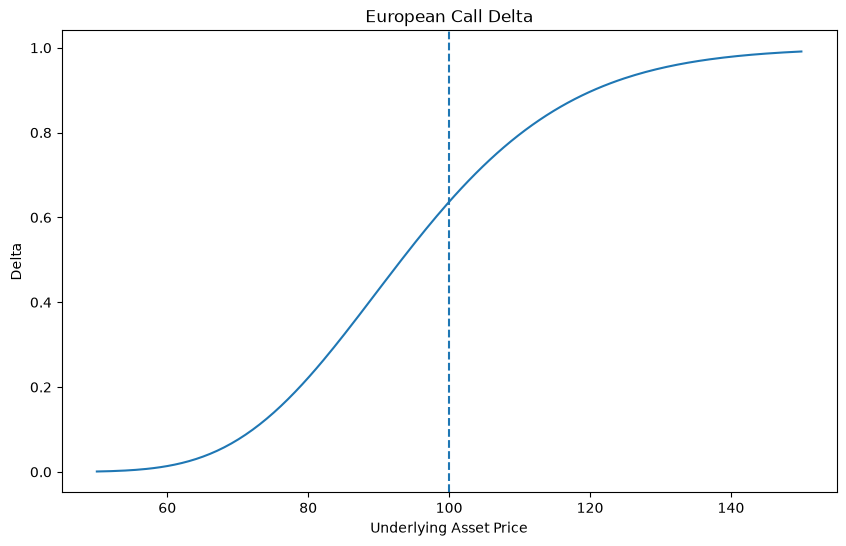

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(spot_prices, delta_values)
plt.axvline(K, linestyle="--")

plt.xlabel("Underlying Asset Price")
plt.ylabel("Delta")
plt.title("European Call Delta")

plt.show()

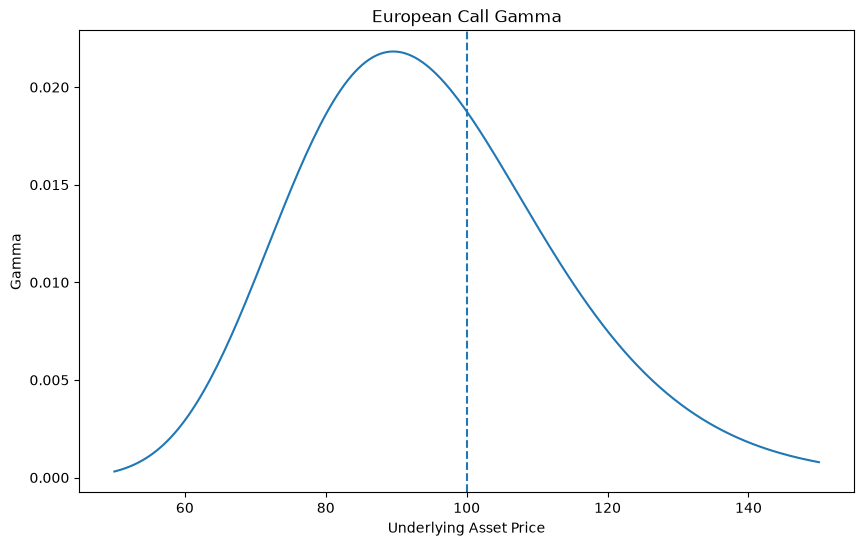

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(spot_prices, gamma_values)
plt.axvline(K, linestyle="--")

plt.xlabel("Underlying Asset Price")
plt.ylabel("Gamma")
plt.title("European Call Gamma")

plt.show()


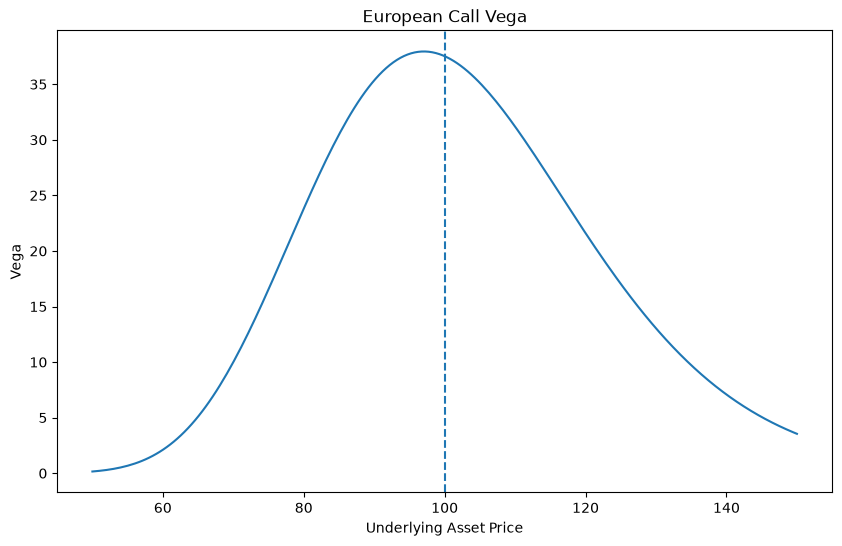

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(spot_prices, vega_values)
plt.axvline(K, linestyle="--")

plt.xlabel("Underlying Asset Price")
plt.ylabel("Vega")
plt.title("European Call Vega")

plt.show()

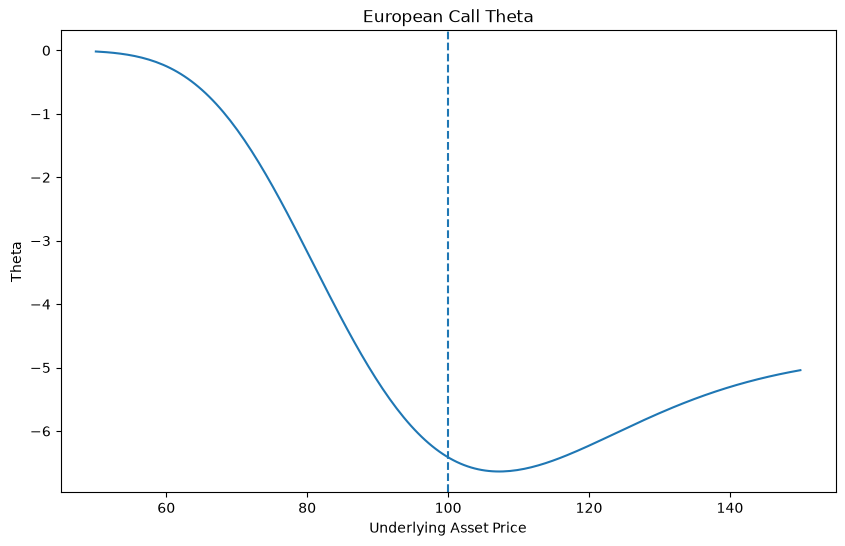

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(spot_prices, theta_values)
plt.axvline(K, linestyle="--")

plt.xlabel("Underlying Asset Price")
plt.ylabel("Theta")
plt.title("European Call Theta")

plt.show()

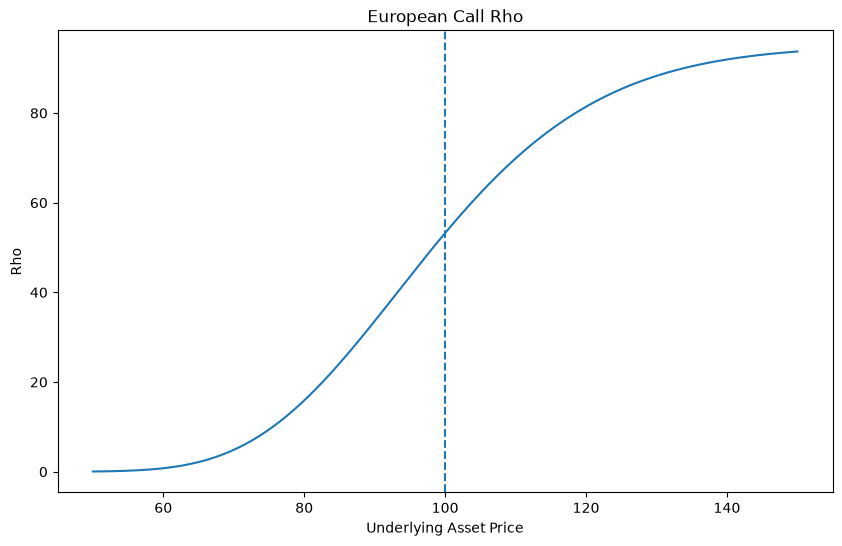

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(spot_prices, rho_values)
plt.axvline(K, linestyle="--")

plt.xlabel("Underlying Asset Price")
plt.ylabel("Rho")
plt.title("European Call Rho")

plt.show()